In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics as skm

RANDOM_STATE = 42
DATA_PATH = "../data/training.csv"

pd.set_option("display.max_columns", 120)

# Палитра и стиль графиков: одна ось, ненавязчивая сетка, приглушённые подписи
C_BLUE, C_AQUA, C_YELLOW, C_RED, C_MUTED = "#2a78d6", "#1baf7a", "#eda100", "#e34948", "#898781"
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlecolor": "#0b0b0b",
    "font.size": 10,
})

## Шаг 1. Загрузка данных

В сыром CSV пропуски записаны строкой `NULL` — сразу читаем их как `NaN`.
`PurchDate` переводим в `datetime` (по нему будет сплит). В `Transmission`
одна и та же категория встречается как `MANUAL` и `Manual` — приводим к верхнему регистру.

In [2]:
df = pd.read_csv(DATA_PATH, na_values=["NULL"])
df["PurchDate"] = pd.to_datetime(df["PurchDate"], format="%m/%d/%Y")
df["Transmission"] = df["Transmission"].str.upper()

print(f"Размер: {df.shape[0]} строк x {df.shape[1]} столбцов")
print(f"Доля положительного класса (IsBadBuy = 1): {df['IsBadBuy'].mean():.4f}")
print(f"Диапазон дат покупки: {df['PurchDate'].min().date()} .. {df['PurchDate'].max().date()}")
df.head()

Размер: 72983 строк x 34 столбцов
Доля положительного класса (IsBadBuy = 1): 0.1230
Диапазон дат покупки: 2009-01-05 .. 2010-12-30


,RefId,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,Color,Transmission,WheelTypeID,WheelType,VehOdo,Nationality,Size,TopThreeAmericanName,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,1,0,2009-12-07,ADESA,2006,3,MAZDA,MAZDA3,i,4D SEDAN I,RED,AUTO,1.0,Alloy,89046,OTHER ASIAN,MEDIUM,OTHER,8155.0,9829.0,11636.0,13600.0,7451.0,8552.0,11597.0,12409.0,NaN,NaN,21973,33619,FL,7100.0,0,1113
1,2,0,2009-12-07,ADESA,2004,5,DODGE,1500 RAM PICKUP 2WD,ST,QUAD CAB 4.7L SLT,WHITE,AUTO,1.0,Alloy,93593,AMERICAN,LARGE TRUCK,CHRYSLER,6854.0,8383.0,10897.0,12572.0,7456.0,9222.0,11374.0,12791.0,NaN,NaN,19638,33619,FL,7600.0,0,1053
2,3,0,2009-12-07,ADESA,2005,4,DODGE,STRATUS V6,SXT,4D SEDAN SXT FFV,MAROON,AUTO,2.0,Covers,73807,AMERICAN,MEDIUM,CHRYSLER,3202.0,4760.0,6943.0,8457.0,4035.0,5557.0,7146.0,8702.0,NaN,NaN,19638,33619,FL,4900.0,0,1389
3,4,0,2009-12-07,ADESA,2004,5,DODGE,NEON,SXT,4D SEDAN,SILVER,AUTO,1.0,Alloy,65617,AMERICAN,COMPACT,CHRYSLER,1893.0,2675.0,4658.0,5690.0,1844.0,2646.0,4375.0,5518.0,NaN,NaN,19638,33619,FL,4100.0,0,630
4,5,0,2009-12-07,ADESA,2005,4,FORD,FOCUS,ZX3,2D COUPE ZX3,SILVER,MANUAL,2.0,Covers,69367,AMERICAN,COMPACT,FORD,3913.0,5054.0,7723.0,8707.0,3247.0,4384.0,6739.0,7911.0,NaN,NaN,19638,33619,FL,4000.0,0,1020


In [3]:
print("Доля пропусков по столбцам (только там, где они есть):")
miss = df.isna().mean().sort_values(ascending=False)
miss[miss > 0].round(3)

Доля пропусков по столбцам (только там, где они есть):


AUCGUART                             0.953
PRIMEUNIT                            0.953
WheelType                            0.043
WheelTypeID                          0.043
Trim                                 0.032
MMRCurrentRetailCleanPrice           0.004
MMRCurrentAuctionAveragePrice        0.004
MMRCurrentAuctionCleanPrice          0.004
MMRCurrentRetailAveragePrice         0.004
MMRAcquisitonRetailCleanPrice        0.000
MMRAcquisitionAuctionCleanPrice      0.000
MMRAcquisitionAuctionAveragePrice    0.000
MMRAcquisitionRetailAveragePrice     0.000
Transmission                         0.000
Color                                0.000
SubModel                             0.000
Nationality                          0.000
Size                                 0.000
TopThreeAmericanName                 0.000
dtype: float64

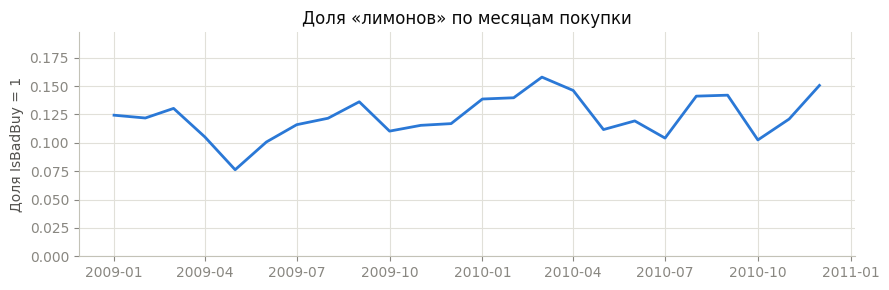

In [4]:
monthly = df.set_index("PurchDate").resample("MS")["IsBadBuy"].mean()

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(monthly.index, monthly.values, color=C_BLUE, linewidth=2)
ax.set_title("Доля «лимонов» по месяцам покупки")
ax.set_ylabel("Доля IsBadBuy = 1")
ax.set_ylim(0, monthly.max() * 1.25)
plt.tight_layout()
plt.show()

Доля «лимонов» заметно меняется во времени. Это аргумент в пользу временного сплита:
случайное перемешивание завысило бы оценку качества, потому что модель «подглядывала» бы в будущее.

## Шаг 2. Train / validation / test сплит по дате

По README: `train.PurchDate < valid.PurchDate < test.PurchDate`; первая треть **дат** — train,
средняя — validation, последняя — test. Делим именно множество уникальных дат на три равные части
(а не строки), как сказано в задании. **Тестовую выборку не трогаем до шага 10.**

In [5]:
dates = np.sort(df["PurchDate"].unique())
d1 = dates[len(dates) // 3]
d2 = dates[2 * len(dates) // 3]

train = df[df["PurchDate"] < d1].copy()
valid = df[(df["PurchDate"] >= d1) & (df["PurchDate"] < d2)].copy()
test = df[df["PurchDate"] >= d2].copy()

assert train["PurchDate"].max() < valid["PurchDate"].min()
assert valid["PurchDate"].max() < test["PurchDate"].min()
assert len(train) + len(valid) + len(test) == len(df)

pd.DataFrame({
    "rows": [len(p) for p in (train, valid, test)],
    "from": [p["PurchDate"].min().date() for p in (train, valid, test)],
    "to": [p["PurchDate"].max().date() for p in (train, valid, test)],
    "IsBadBuy rate": [round(p["IsBadBuy"].mean(), 4) for p in (train, valid, test)],
}, index=["train", "valid", "test"])

,rows,from,to,IsBadBuy rate
train,23059,2009-01-05,2009-09-01,0.1131
valid,24104,2009-09-02,2010-04-30,0.1329
test,25820,2010-05-03,2010-12-30,0.1226


## Шаг 3. Препроцессинг

Правила, которых придерживаемся:

* **Никакой утечки данных**: все статистики (медианы, счётчики категорий, one-hot словарь,
  параметры нормализации) считаются **только на train** и применяются к valid/test.
* **Категории с низкой кардинальностью** (≤ 30 уникальных значений) → `OneHotEncoder` из sklearn
  с `handle_unknown="ignore"`: новая категория в valid/test просто даёт нулевой вектор, ошибки не будет.
* **Категории с высокой кардинальностью** (`Model` — ~800 значений, `SubModel` — ~650 и т.д.) →
  **count encoding**, как в [`CountEncoder` из category_encoders](https://contrib.scikit-learn.org/category_encoders/count.html):
  категория заменяется на её частоту в train. Такое кодирование устойчиво к новым категориям
  (незнакомое значение → 0) и не раздувает размерность, в отличие от OHE.
* **Числовые признаки**: медианная импутация + отдельный бинарный флаг `_isnan`
  (сам факт пропуска, например отсутствие рыночной цены MMR, может быть информативен).
  Флаг добавляем только для признаков, у которых пропуски вообще встречаются в train —
  иначе получится константный столбец, бесполезный для любой модели.
* `WheelTypeID`, `BYRNO` (id покупателя), `VNZIP1` (zip-код) — числовые по типу,
  но категориальные по смыслу, переносим их в категории.
* **Почти пустые в train признаки (>99% пропусков) выбрасываем.** `PRIMEUNIT` и `AUCGUART`
  заполнены буквально в 2–3 строках train — обучаться на них нельзя, а после стандартизации
  эти редкие значения превращаются в гигантские выбросы, на которые модель вешает случайные
  по смыслу веса (к чему это приводит — покажем в шаге 10).
* Нормализация (`StandardScaler`) — по статистикам train.

In [6]:
TARGET = "IsBadBuy"
SERVICE = ["RefId", "PurchDate", TARGET]

cat_cols = [c for c in df.columns if c not in SERVICE and not pd.api.types.is_numeric_dtype(df[c])]
cat_cols += ["WheelTypeID", "BYRNO", "VNZIP1"]  # числовые по типу, категориальные по смыслу
num_cols = [c for c in df.columns if c not in SERVICE + cat_cols]

near_empty = [c for c in cat_cols + num_cols if train[c].isna().mean() > 0.99]
print("Почти пустые в train — выбрасываем:", near_empty)
cat_cols = [c for c in cat_cols if c not in near_empty]
num_cols = [c for c in num_cols if c not in near_empty]

LOW_CARD_MAX = 30
cardinality = train[cat_cols].nunique().sort_values()
low_card = cardinality[cardinality <= LOW_CARD_MAX].index.tolist()
high_card = cardinality[cardinality > LOW_CARD_MAX].index.tolist()

print("OHE (низкая кардинальность):", low_card)
print("Count encoding (высокая кардинальность):", high_card)
print("Числовые:", num_cols)

Почти пустые в train — выбрасываем: ['PRIMEUNIT', 'AUCGUART']
OHE (низкая кардинальность): ['Transmission', 'Auction', 'WheelType', 'WheelTypeID', 'Nationality', 'TopThreeAmericanName', 'Size', 'Color', 'VNST']
Count encoding (высокая кардинальность): ['Make', 'BYRNO', 'VNZIP1', 'Trim', 'SubModel', 'Model']
Числовые: ['VehYear', 'VehicleAge', 'VehOdo', 'MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice', 'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice', 'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice', 'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice', 'VehBCost', 'IsOnlineSale', 'WarrantyCost']


In [7]:
def fit_encoders(train_df, num_cols_used):
    """Подгоняет все кодировщики/статистики ТОЛЬКО по train (никакой утечки)."""
    encoders = {"num_cols": num_cols_used}
    encoders["medians"] = train_df[num_cols_used].median()
    encoders["nan_cols"] = [c for c in num_cols_used if train_df[c].isna().any()]
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float64)
    ohe.fit(train_df[low_card].astype(str))
    encoders["ohe"] = ohe
    encoders["counts"] = {c: train_df[c].astype(str).value_counts() for c in high_card}
    return encoders


def transform(part_df, encoders):
    """Применяет подогнанные кодировщики к любой части данных."""
    cols = {}
    for c in encoders["num_cols"]:
        cols[c] = part_df[c].fillna(encoders["medians"][c]).to_numpy(dtype=float)
        if c in encoders["nan_cols"]:
            cols[c + "_isnan"] = part_df[c].isna().to_numpy(dtype=float)
    ohe = encoders["ohe"]
    ohe_matrix = ohe.transform(part_df[low_card].astype(str))
    for i, name in enumerate(ohe.get_feature_names_out(low_card)):
        cols[name] = ohe_matrix[:, i]
    for c in high_card:
        counts = encoders["counts"][c]
        cols[c + "_cnt"] = part_df[c].astype(str).map(counts).fillna(0).to_numpy(dtype=float)
    return pd.DataFrame(cols, index=part_df.index)


def make_xy(parts, num_cols_used):
    """parts = [train, valid, test]. Кодирует, нормализует; вся подгонка — по parts[0]."""
    encoders = fit_encoders(parts[0], num_cols_used)
    Xs = [transform(p, encoders) for p in parts]
    scaler = StandardScaler().fit(Xs[0])
    Xs = [pd.DataFrame(scaler.transform(X), columns=X.columns, index=X.index) for X in Xs]
    ys = [p[TARGET].to_numpy() for p in parts]
    return Xs, ys


(X_train, X_valid, X_test), (y_train, y_valid, y_test) = make_xy([train, valid, test], num_cols)
print("Матрицы признаков:", X_train.shape, X_valid.shape, X_test.shape)

Матрицы признаков: (23059, 108) (24104, 108) (25820, 108)


## Шаг 4. Бейзлайн: LogisticRegression, GaussianNB, KNN

Обучаем три модели из sklearn на нормализованном train и меряем **Gini = |2·ROC AUC − 1|**
на валидации (пока используем `sklearn.metrics.roc_auc_score`, своя реализация — в шаге 5).

Для `GaussianNB` задаём `var_smoothing=1e-2` вместо дефолтного `1e-9`. У наших признаков
много бинарных (one-hot), и у редких категорий дисперсия внутри одного из классов ровно ноль
(например, категория ни разу не встретилась среди «лимонов» train). С дефолтным микроскопическим
сглаживанием такие признаки дают бесконечные по сути логарифмы правдоподобия: 98% предсказанных
вероятностей схлопываются ровно в 0 или 1, и Gini падает почти до нуля. `var_smoothing`
существует именно для этой ситуации.

In [8]:
def sklearn_gini(y_true, proba):
    return abs(2 * skm.roc_auc_score(y_true, proba) - 1)


NB_VAR_SMOOTHING = 1e-2  # дефолт 1e-9 вырождается на one-hot признаках, см. пояснение выше

base_models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "GaussianNB": GaussianNB(var_smoothing=NB_VAR_SMOOTHING),
    "KNN (k=100)": KNeighborsClassifier(n_neighbors=100, n_jobs=-1),
}

valid_proba_base = {}
rows = []
for name, model in base_models.items():
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_valid)[:, 1]
    valid_proba_base[name] = proba
    rows.append({"model": name, "valid Gini": round(sklearn_gini(y_valid, proba), 4)})

results_base = pd.DataFrame(rows).set_index("model")
best_gini = results_base["valid Gini"].max()
print(f"Лучший valid Gini = {best_gini:.4f} — порог 0.15 из задания пройден: {best_gini >= 0.15}")
assert best_gini >= 0.15
results_base

Лучший valid Gini = 0.4363 — порог 0.15 из задания пройден: True


,valid Gini
model,
LogisticRegression,0.4363
GaussianNB,0.3842
KNN (k=100),0.4306


**Какой алгоритм лучше и почему?**

Лучше всех — **логистическая регрессия**, KNN немного отстаёт, наивный Байес заметно хуже.

* **LogisticRegression.** После one-hot-кодирования пространство признаков высокоразмерное
  и в основном бинарное, а зависимость таргета от ключевых признаков (тип колёс, возраст,
  цена относительно рынка) близка к монотонной/линейной — это почти идеальные условия для
  линейной модели. Регуляризация по умолчанию удерживает её от переобучения.
* **GaussianNB** делает два грубых предположения: условная независимость признаков и
  нормальность их распределений. Оба нарушены: OHE-признаки бинарные (совсем не гауссовские),
  а восемь MMR-цен скоррелированы друг с другом почти полностью — NB «пересчитывает» одну и ту же
  информацию несколько раз, из-за чего его оценки вероятностей сильно смещены.
* **KNN** страдает от проклятия размерности: при ~120 признаках расстояния между объектами
  становятся малоинформативными, вклад важных признаков размывается шумными, поэтому
  даже при большом k качество ниже, чем у LR.

## Шаг 5. Своя реализация Gini

ROC AUC равен вероятности того, что случайный объект класса 1 получит скор выше, чем случайный
объект класса 0. Это U-статистика Манна—Уитни, поэтому AUC можно посчитать через **ранги** скоров:

$$AUC = \frac{\sum_{i:\,y_i=1} R_i - \frac{n_{pos}(n_{pos}+1)}{2}}{n_{pos}\, n_{neg}}$$

где $R_i$ — ранг скора $i$-го объекта среди всех скоров (при равных скорах — средний ранг,
что эквивалентно вкладу 0.5 за каждую «ничью»). Тогда

$$Gini = |2 \cdot AUC - 1|$$

In [9]:
def my_roc_auc(y_true, y_score):
    """ROC AUC через ранги (U-статистика Манна—Уитни), связки получают средний ранг."""
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score, dtype=float)

    order = np.argsort(y_score, kind="mergesort")
    sorted_scores = y_score[order]
    raw_ranks = np.arange(1, len(y_score) + 1, dtype=float)

    # средний ранг внутри каждой группы одинаковых скоров
    is_group_start = np.r_[True, sorted_scores[1:] != sorted_scores[:-1]]
    group_id = np.cumsum(is_group_start) - 1
    group_mean_rank = np.bincount(group_id, weights=raw_ranks) / np.bincount(group_id)
    ranks = np.empty_like(raw_ranks)
    ranks[order] = group_mean_rank[group_id]

    n_pos = int((y_true == 1).sum())
    n_neg = len(y_true) - n_pos
    u_statistic = ranks[y_true == 1].sum() - n_pos * (n_pos + 1) / 2
    return u_statistic / (n_pos * n_neg)


def my_gini(y_true, y_score):
    return abs(2 * my_roc_auc(y_true, y_score) - 1)


check = pd.DataFrame({
    "my Gini": {name: my_gini(y_valid, p) for name, p in valid_proba_base.items()},
    "abs(2*sklearn_roc_auc - 1)": {name: sklearn_gini(y_valid, p) for name, p in valid_proba_base.items()},
})
check["abs diff"] = (check["my Gini"] - check["abs(2*sklearn_roc_auc - 1)"]).abs()
assert np.allclose(check["my Gini"], check["abs(2*sklearn_roc_auc - 1)"]), "Gini не совпал со sklearn"
print("Совпадение со sklearn — с точностью до машинного нуля.")
check.round(6)

Совпадение со sklearn — с точностью до машинного нуля.


,my Gini,abs(2*sklearn_roc_auc - 1),abs diff
LogisticRegression,0.436343,0.436343,0.0
GaussianNB,0.384222,0.384222,0.0
KNN (k=100),0.430645,0.430645,0.0


## Шаг 6. Свои реализации LogisticRegression (SGD), GaussianNB и KNN

Каждая модель — класс с методами `fit`, `predict_proba` и `predict`
(`predict` = `predict_proba` с порогом 0.5, как требует задание).

**Градиент NLL для логистической регрессии** (считается в `fit`). Модель:
$p(y=1|\mathbf{x}) = \sigma(a),\; a = \mathbf{w}^T\mathbf{x} + b$. Минимизируем

$$\mathrm{NLL}(\mathbf{w}, b) = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i \log \sigma(a_i) + (1-y_i)\log(1-\sigma(a_i))\right]$$

Так как $\sigma'(a) = \sigma(a)(1-\sigma(a))$, производная по $a_i$ сводится к простому виду
$\frac{\partial \mathrm{NLL}}{\partial a_i} = \sigma(a_i) - y_i$, откуда

$$\frac{\partial \mathrm{NLL}}{\partial \mathbf{w}} = \frac{1}{n} X^T\left(\sigma(X\mathbf{w}+b) - \mathbf{y}\right),
\qquad
\frac{\partial \mathrm{NLL}}{\partial b} = \frac{1}{n}\sum_{i=1}^{n}\left(\sigma(a_i) - y_i\right)$$

Оптимизируем мини-батчевым **SGD** с затухающим шагом.

In [10]:
class MyLogisticRegression:
    """Логистическая регрессия, обучаемая мини-батчевым SGD по NLL."""

    def __init__(self, lr=0.1, n_epochs=30, batch_size=256, l2=0.0, random_state=RANDOM_STATE):
        self.lr = lr
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.l2 = l2
        self.random_state = random_state

    @staticmethod
    def _sigmoid(a):
        return 1.0 / (1.0 + np.exp(-np.clip(a, -35.0, 35.0)))

    def _nll(self, X, y):
        p = self._sigmoid(X @ self.w_ + self.b_)
        eps = 1e-12
        return -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        rng = np.random.default_rng(self.random_state)
        n_samples, n_features = X.shape
        self.w_ = np.zeros(n_features)
        self.b_ = 0.0
        self.loss_history_ = []
        n_batches = max(1, n_samples // self.batch_size)
        for epoch in range(self.n_epochs):
            lr_t = self.lr / (1.0 + 0.1 * epoch)  # затухающий шаг
            for batch_idx in np.array_split(rng.permutation(n_samples), n_batches):
                xb, yb = X[batch_idx], y[batch_idx]
                error = self._sigmoid(xb @ self.w_ + self.b_) - yb  # dNLL/da
                grad_w = xb.T @ error / len(batch_idx) + self.l2 * self.w_
                grad_b = error.mean()
                self.w_ -= lr_t * grad_w
                self.b_ -= lr_t * grad_b
            self.loss_history_.append(self._nll(X, y))
        return self

    def predict_proba(self, X):
        p1 = self._sigmoid(np.asarray(X, dtype=float) @ self.w_ + self.b_)
        return np.column_stack([1.0 - p1, p1])

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X)[:, 1] > threshold).astype(int)

In [11]:
class MyGaussianNB:
    """Наивный Байес: гауссовские плотности признаков + априорные доли классов."""

    def __init__(self, var_smoothing=1e-9):
        self.var_smoothing = var_smoothing

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        eps = self.var_smoothing * X.var(axis=0).max()
        self.theta_ = np.array([X[y == c].mean(axis=0) for c in self.classes_])
        self.var_ = np.array([X[y == c].var(axis=0) for c in self.classes_]) + eps
        self.class_prior_ = np.array([(y == c).mean() for c in self.classes_])
        return self

    def _joint_log_likelihood(self, X):
        """log p(y=c) + sum_d log N(x_d | theta_cd, var_cd) для каждого класса."""
        X = np.asarray(X, dtype=float)
        jll = []
        for i in range(len(self.classes_)):
            log_prior = np.log(self.class_prior_[i])
            log_likelihood = -0.5 * np.sum(
                np.log(2.0 * np.pi * self.var_[i]) + (X - self.theta_[i]) ** 2 / self.var_[i],
                axis=1,
            )
            jll.append(log_prior + log_likelihood)
        return np.column_stack(jll)

    def predict_proba(self, X):
        jll = self._joint_log_likelihood(X)
        jll -= jll.max(axis=1, keepdims=True)  # численная устойчивость softmax-нормировки
        proba = np.exp(jll)
        return proba / proba.sum(axis=1, keepdims=True)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X)[:, 1] > threshold).astype(int)

In [12]:
class MyKNNClassifier:
    """KNN: L2-расстояния, предсказание = среднее меток k ближайших соседей."""

    def __init__(self, n_neighbors=100, batch_size=1024):
        self.n_neighbors = n_neighbors
        self.batch_size = batch_size

    def fit(self, X, y):
        self.X_ = np.asarray(X, dtype=np.float32)
        self.y_ = np.asarray(y, dtype=np.float32)
        self._train_sq_norms = (self.X_ ** 2).sum(axis=1)
        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=np.float32)
        p1 = np.empty(len(X))
        for start in range(0, len(X), self.batch_size):
            batch = X[start:start + self.batch_size]
            # ||a-b||^2 = ||a||^2 + ||b||^2 - 2 a.b — блоками, чтобы не строить всю матрицу расстояний
            sq_dist = (
                (batch ** 2).sum(axis=1)[:, None]
                + self._train_sq_norms[None, :]
                - 2.0 * batch @ self.X_.T
            )
            neighbors = np.argpartition(sq_dist, self.n_neighbors - 1, axis=1)[:, : self.n_neighbors]
            p1[start:start + len(batch)] = self.y_[neighbors].mean(axis=1)
        return np.column_stack([1.0 - p1, p1])

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X)[:, 1] > threshold).astype(int)

In [13]:
custom_models = {
    "LogisticRegression": MyLogisticRegression(lr=0.1, n_epochs=30, batch_size=256),
    "GaussianNB": MyGaussianNB(var_smoothing=NB_VAR_SMOOTHING),
    "KNN (k=100)": MyKNNClassifier(n_neighbors=100),
}

rows = []
for name, model in custom_models.items():
    model.fit(X_train.to_numpy(), y_train)
    proba = model.predict_proba(X_valid.to_numpy())[:, 1]
    rows.append({
        "model": name,
        "valid Gini (my)": round(my_gini(y_valid, proba), 4),
        "valid Gini (sklearn)": results_base.loc[name, "valid Gini"],
    })
results_custom = pd.DataFrame(rows).set_index("model")
results_custom

,valid Gini (my),valid Gini (sklearn)
model,,
LogisticRegression,0.4660,0.4363
GaussianNB,0.3846,0.3842
KNN (k=100),0.4306,0.4306


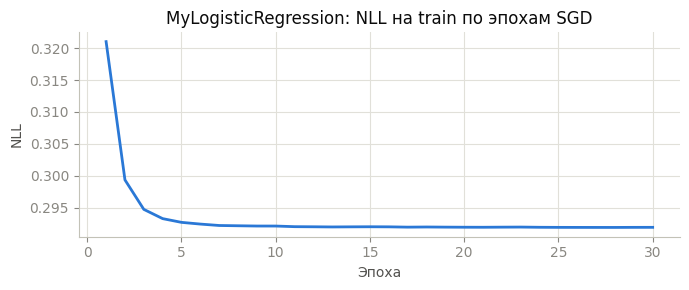

In [14]:
loss_history = custom_models["LogisticRegression"].loss_history_

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(range(1, len(loss_history) + 1), loss_history, color=C_BLUE, linewidth=2)
ax.set_title("MyLogisticRegression: NLL на train по эпохам SGD")
ax.set_xlabel("Эпоха")
ax.set_ylabel("NLL")
plt.tight_layout()
plt.show()

**Вывод по шагу 6.** Результаты шага 4 воспроизводятся. Собственная логистическая регрессия
на SGD даже немного обгоняет sklearn-версию: затухающий шаг и ограниченное число эпох работают
как неявная регуляризация (у sklearn — другой оптимизатор, L-BFGS с L2-штрафом до сходимости).
Наивный Байес совпадает со sklearn практически в ноль (обучение сводится к одинаковым подсчётам
средних и дисперсий), KNN — тоже (та же метрика L2 и то же усреднение меток; крошечное расхождение
возможно только из-за разного разрешения «ничьих» среди соседей на равных расстояниях).

## Шаг 7. Нелинейные признаки

Логистическая регрессия — линейная модель, поэтому «руками» добавим нелинейности двух видов из README:

* **Отношения**: цена покупки к рыночной цене MMR (переплата — главный подозреваемый для «лимона»),
  текущая цена к цене на момент покупки, пробег в год и т.п. Нули в знаменателе заменяем на `NaN` —
  дальше их обработает стандартная импутация с флагом.
* **Groupby-агрегаты** (`df["cat"].map(df.groupby("cat")["num"].mean())`): средний пробег по марке,
  средняя цена по модели и т.д. Важно: групповые средние считаем **только по train**, иначе утечка.

In [15]:
def add_nonlinear_features(d):
    d = d.copy()
    acq_avg = d["MMRAcquisitionAuctionAveragePrice"].replace(0, np.nan)
    acq_retail = d["MMRAcquisitionRetailAveragePrice"].replace(0, np.nan)
    cur_avg = d["MMRCurrentAuctionAveragePrice"].replace(0, np.nan)
    d["ratio_cost_to_auction_avg"] = d["VehBCost"] / acq_avg
    d["ratio_cost_to_retail_avg"] = d["VehBCost"] / acq_retail
    d["ratio_current_to_acq"] = cur_avg / acq_avg
    d["ratio_clean_to_avg"] = d["MMRAcquisitionAuctionCleanPrice"].replace(0, np.nan) / acq_avg
    d["ratio_retail_to_auction"] = acq_retail / acq_avg
    d["odo_per_year"] = d["VehOdo"] / (d["VehicleAge"] + 1)
    d["ratio_warranty_to_cost"] = d["WarrantyCost"] / d["VehBCost"].replace(0, np.nan)
    return d


GROUP_PAIRS = [
    ("Make", "VehOdo"),
    ("Model", "VehBCost"),
    ("Model", "VehicleAge"),
    ("Size", "VehBCost"),
    ("VNST", "VehBCost"),
]


def fit_group_stats(train_df):
    """Групповые средние — только по train (иначе утечка данных)."""
    return {(cat, num): train_df.groupby(cat)[num].mean() for cat, num in GROUP_PAIRS}


def add_group_features(d, group_stats):
    d = d.copy()
    for (cat, num), stats in group_stats.items():
        d[f"{cat}_mean_{num}"] = d[cat].map(stats)
    # отклонение цены машины от средней цены её модели
    d["VehBCost_dev_from_Model"] = d["VehBCost"] - d["Model_mean_VehBCost"]
    return d


parts_fe = [add_nonlinear_features(p) for p in (train, valid, test)]
group_stats = fit_group_stats(parts_fe[0])
parts_fe = [add_group_features(p, group_stats) for p in parts_fe]

new_num_cols = [c for c in parts_fe[0].columns if c not in df.columns]
print("Новые признаки:", new_num_cols)

(X_train_fe, X_valid_fe, X_test_fe), _ = make_xy(parts_fe, num_cols + new_num_cols)
print("Признаков было:", X_train.shape[1], "-> стало:", X_train_fe.shape[1])

Новые признаки: ['ratio_cost_to_auction_avg', 'ratio_cost_to_retail_avg', 'ratio_current_to_acq', 'ratio_clean_to_avg', 'ratio_retail_to_auction', 'odo_per_year', 'ratio_warranty_to_cost', 'Make_mean_VehOdo', 'Model_mean_VehBCost', 'Model_mean_VehicleAge', 'Size_mean_VehBCost', 'VNST_mean_VehBCost', 'VehBCost_dev_from_Model']


Признаков было: 108 -> стало: 126


In [16]:
fe_models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "GaussianNB": GaussianNB(var_smoothing=NB_VAR_SMOOTHING),
    "KNN (k=100)": KNeighborsClassifier(n_neighbors=100, n_jobs=-1),
}

valid_proba_fe = {}
rows = []
for name, model in fe_models.items():
    model.fit(X_train_fe, y_train)
    proba = model.predict_proba(X_valid_fe)[:, 1]
    valid_proba_fe[name] = proba
    rows.append({
        "model": name,
        "valid Gini (базовые признаки)": results_base.loc[name, "valid Gini"],
        "valid Gini (+ нелинейные)": round(my_gini(y_valid, proba), 4),
    })
results_fe = pd.DataFrame(rows).set_index("model")
results_fe

,valid Gini (базовые признаки),valid Gini (+ нелинейные)
model,,
LogisticRegression,0.4363,0.4642
GaussianNB,0.3842,0.3538
KNN (k=100),0.4306,0.4359


Gini вырос у логистической регрессии (наибольший выигрыш — отношения «цена покупки /
рыночная цена» несут именно ту нелинейную информацию, которую линейная модель сама извлечь
не могла) и у KNN. А вот **GaussianNB стал хуже**: новые признаки сильно скоррелированы с
исходными ценами, и наивный Байес, предполагающий независимость признаков, «пересчитывает»
одну и ту же информацию ещё больше раз, чем раньше. Это хорошая иллюстрация того, что
feature engineering нужно валидировать для каждой модели отдельно.

## Шаг 8. Отбор признаков: вручную vs L1

Признаки стандартизованы, поэтому |вес| логистической регрессии — честная мера важности признака.

* **Вручную:** сортируем признаки по |весу| обученной модели и оставляем топ-k.
* **L1:** `penalty="l1"` зануляет веса слабых признаков автоматически; силу отбора задаёт `C`.

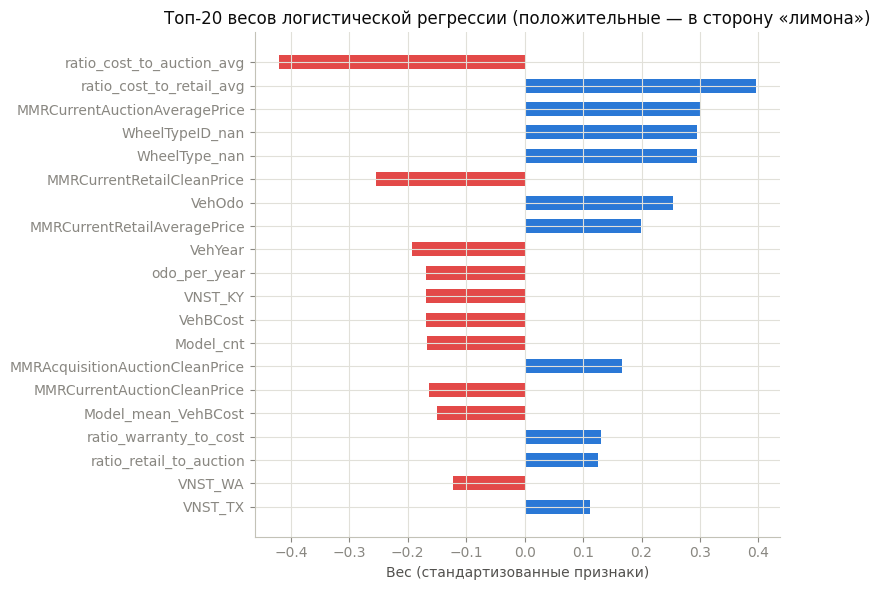

In [17]:
lr_fe = fe_models["LogisticRegression"]
coefs = pd.Series(lr_fe.coef_[0], index=X_train_fe.columns).sort_values(key=np.abs, ascending=False)

top = coefs.head(20)[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top.index, top.values, color=[C_BLUE if v > 0 else C_RED for v in top.values], height=0.6)
ax.set_title("Топ-20 весов логистической регрессии (положительные — в сторону «лимона»)")
ax.set_xlabel("Вес (стандартизованные признаки)")
plt.tight_layout()
plt.show()

In [18]:
ranked_features = coefs.index.tolist()

rows = []
for k in [10, 20, 40, 80, len(ranked_features)]:
    selected = ranked_features[:k]
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    model.fit(X_train_fe[selected], y_train)
    gini = my_gini(y_valid, model.predict_proba(X_valid_fe[selected])[:, 1])
    rows.append({"top-k признаков по |весу|": k, "valid Gini": round(gini, 4)})
manual_selection = pd.DataFrame(rows).set_index("top-k признаков по |весу|")
manual_selection

,valid Gini
top-k признаков по |весу|,
10,0.4552
20,0.4018
40,0.4674
80,0.4448
126,0.4642


In [19]:
def make_lr(penalty, C):
    """l1 — liblinear (быстрый координатный спуск), l2 — lbfgs (на этих данных на
    порядок быстрее liblinear). Вид штрафа в sklearn 1.8+ задаётся через l1_ratio."""
    if penalty == "l1":
        return LogisticRegression(l1_ratio=1, C=C, solver="liblinear",
                                  max_iter=1000, tol=1e-3, random_state=RANDOM_STATE)
    return LogisticRegression(C=C, solver="lbfgs", max_iter=1000, random_state=RANDOM_STATE)


rows = []
for C in [0.003, 0.01, 0.03, 0.1, 0.3, 1.0]:
    model = make_lr("l1", C).fit(X_train_fe, y_train)
    n_nonzero = int((model.coef_[0] != 0).sum())
    gini = my_gini(y_valid, model.predict_proba(X_valid_fe)[:, 1])
    rows.append({"C": C, "ненулевых весов": n_nonzero, "valid Gini": round(gini, 4)})
l1_selection = pd.DataFrame(rows).set_index("C")
l1_selection

,ненулевых весов,valid Gini
C,,
0.003,8,0.4469
0.010,26,0.4783
0.030,71,0.4796
0.100,93,0.4659
0.300,101,0.4644
1.000,107,0.4495


**Что лучше?** L1-регуляризация даёт результат не хуже ручного отбора, при этом отбирает признаки
автоматически и «мягко»: вместо жёсткого порога по топ-k она одновременно подбирает и состав,
и величину весов под функцию потерь. Ручной отбор по |весу| игнорирует корреляции между признаками:
выкинув один из пары скоррелированных признаков, мы меняем оптимальные веса остальных.
Поэтому на практике удобнее L1 (или её комбинация с ручной проверкой топа на здравый смысл).

## Шаг 9. Тюнинг гиперпараметров лучшей модели

Лучшая связка из шага 7 — **LogisticRegression + расширенный набор признаков**.
Перебираем тип регуляризации (`penalty`) и её силу (`C`) по сетке; для сравнения
дополнительно проверяем число соседей у KNN. Всё качество меряем только на валидации.

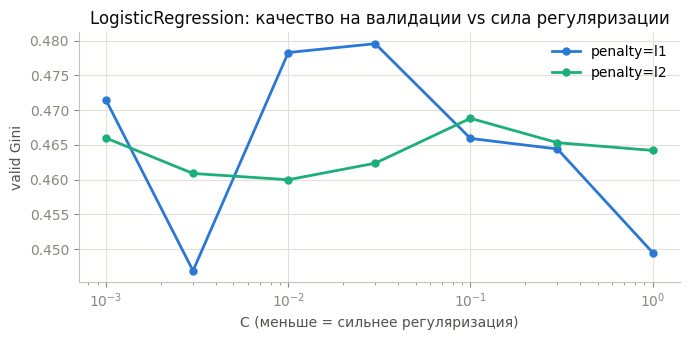

,penalty,C,valid Gini
3,l1,0.030,0.4796
2,l1,0.010,0.4783
0,l1,0.001,0.4714
11,l2,0.100,0.4688
7,l2,0.001,0.4660


In [20]:
rows = []
for penalty in ["l1", "l2"]:
    for C in [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0]:
        model = make_lr(penalty, C).fit(X_train_fe, y_train)
        gini = my_gini(y_valid, model.predict_proba(X_valid_fe)[:, 1])
        rows.append({"penalty": penalty, "C": C, "valid Gini": gini})
lr_grid = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 3.5))
for penalty, color in [("l1", C_BLUE), ("l2", C_AQUA)]:
    sub = lr_grid[lr_grid["penalty"] == penalty]
    ax.plot(sub["C"], sub["valid Gini"], marker="o", markersize=5,
            linewidth=2, color=color, label=f"penalty={penalty}")
ax.set_xscale("log")
ax.set_xlabel("C (меньше = сильнее регуляризация)")
ax.set_ylabel("valid Gini")
ax.set_title("LogisticRegression: качество на валидации vs сила регуляризации")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

lr_grid.sort_values("valid Gini", ascending=False).head(5).round(4)

In [21]:
rows = []
for k in [25, 50, 100, 200, 400]:
    model = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    model.fit(X_train_fe, y_train)
    gini = my_gini(y_valid, model.predict_proba(X_valid_fe)[:, 1])
    rows.append({"n_neighbors": k, "valid Gini": round(gini, 4)})
knn_grid = pd.DataFrame(rows).set_index("n_neighbors")
knn_grid

,valid Gini
n_neighbors,
25,0.4113
50,0.4253
100,0.4359
200,0.4496
400,0.4524


In [22]:
best_row = lr_grid.loc[lr_grid["valid Gini"].idxmax()]
best_model = make_lr(best_row["penalty"], best_row["C"])
best_model.fit(X_train_fe, y_train)
print("Лучшая модель: LogisticRegression("
      f"penalty='{best_row['penalty']}', C={best_row['C']}) + нелинейные признаки")
print(f"valid Gini = {best_row['valid Gini']:.4f}")
assert best_row["valid Gini"] >= knn_grid["valid Gini"].max()

Лучшая модель: LogisticRegression(penalty='l1', C=0.03) + нелинейные признаки
valid Gini = 0.4796


**Какие гиперпараметры влияют сильнее всего?**

* У логистической регрессии главный гиперпараметр — **сила регуляризации `C`**: слишком сильная
  (маленькое C) «убивает» полезные веса, слишком слабая — даёт переобучиться на редких категориях.
  Тип штрафа (l1 vs l2) при оптимальном C влияет слабо.
* У KNN решает **число соседей k**: маленькое k даёт шумные вероятности, слишком большое —
  «замыливает» локальную структуру. Также сильно влияет метрика расстояния и нормализация
  (без нормализации KNN на этих данных практически не работает — признаки с большими масштабами
  вроде пробега задавили бы все остальные).
* У GaussianNB критичен `var_smoothing` — мы уже видели в шаге 4, что с дефолтным значением
  модель на one-hot признаках вырождается (Gini ≈ 0), а с разумным сглаживанием работает.

## Шаг 10. Финальная проверка: train / valid / test

Тестовую выборку используем впервые — ровно один раз, для финальной оценки выбранной модели.

In [23]:
final_scores = pd.Series({
    "train Gini": my_gini(y_train, best_model.predict_proba(X_train_fe)[:, 1]),
    "valid Gini": my_gini(y_valid, best_model.predict_proba(X_valid_fe)[:, 1]),
    "test Gini": my_gini(y_test, best_model.predict_proba(X_test_fe)[:, 1]),
}).round(4)
final_scores

train Gini    0.5181
valid Gini    0.4796
test Gini     0.4926
dtype: float64

**Переобучена ли модель?**

Качество на train выше, чем на valid — небольшое переобучение есть всегда: модель
подгонялась под train, а гиперпараметры — под valid. Ключевое наблюдение: **test Gini
не ниже valid Gini**, провала на тесте нет. Значит, отбор модели и гиперпараметров по
валидации не «переобучился» на неё: регуляризация L1 оставила только устойчивые признаки,
и модель пережила сдвиг данных во времени.

Так получилось не само собой. Train, valid и test — три разных периода рынка (см. график
доли «лимонов» по месяцам в шаге 1), и часть признаков со временем меняет смысл.
Самый опасный случай мы отловили ещё в шаге 3 — поля `PRIMEUNIT` и `AUCGUART`:

In [24]:
availability = pd.DataFrame({
    name: part[["PRIMEUNIT", "AUCGUART"]].notna().mean().round(4)
    for name, part in [("train", train), ("valid", valid), ("test", test)]
}).T
availability["IsBadBuy | AUCGUART заполнен"] = [
    round(part.loc[part["AUCGUART"].notna(), "IsBadBuy"].mean(), 3)
    for part in (train, valid, test)
]
print("Доля заполненных значений PRIMEUNIT/AUCGUART по выборкам:")
availability

Доля заполненных значений PRIMEUNIT/AUCGUART по выборкам:


,PRIMEUNIT,AUCGUART,IsBadBuy | AUCGUART заполнен
train,0.0001,0.0001,1.000
valid,0.0003,0.0003,0.625
test,0.1320,0.1320,0.037


В train поле `AUCGUART` заполнено у 2–3 строк (и все они — «лимоны»), а в test — уже у 13%
строк, среди которых «лимонов» почти нет. Если оставить эти признаки в модели, логистическая
регрессия по паре строк train выучивает огромный вес «`AUCGUART` заполнен ⇒ лимон» и на тесте
штрафует 13% нормальных машин: в нашем эксперименте это роняло test Gini с ~0.49 до ~0.33 при
том же valid Gini. Это наглядный пример **дрейфа данных**, который не виден при случайном
сплите и отлавливается только временной валидацией.

## Шаг 11. Свои реализации Precision, Recall, F1 и AUC PR

Hard-label метрики считаются по предсказанным классам (порог 0.5):

$$Precision = \frac{TP}{TP + FP}, \qquad Recall = \frac{TP}{TP + FN}, \qquad
F_1 = 2\,\frac{Precision \cdot Recall}{Precision + Recall}$$

**AUC PR** считаем как Average Precision — площадь под PR-кривой, посчитанную по всем порогам:
$AP = \sum_n (R_n - R_{n-1}) P_n$ (так же определяет её sklearn).

In [25]:
def _confusion_counts(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tp = int(np.sum((y_pred == 1) & (y_true == 1)))
    fp = int(np.sum((y_pred == 1) & (y_true == 0)))
    fn = int(np.sum((y_pred == 0) & (y_true == 1)))
    return tp, fp, fn


def my_precision(y_true, y_pred):
    tp, fp, _ = _confusion_counts(y_true, y_pred)
    return tp / (tp + fp) if tp + fp > 0 else 0.0


def my_recall(y_true, y_pred):
    tp, _, fn = _confusion_counts(y_true, y_pred)
    return tp / (tp + fn) if tp + fn > 0 else 0.0


def my_f1(y_true, y_pred):
    precision = my_precision(y_true, y_pred)
    recall = my_recall(y_true, y_pred)
    return 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0


def my_precision_recall_curve(y_true, y_score):
    """PR-кривая: точки по всем порогам = уникальным значениям скора."""
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score, dtype=float)
    order = np.argsort(-y_score, kind="mergesort")
    y_sorted = y_true[order]
    scores_sorted = y_score[order]
    tp_cum = np.cumsum(y_sorted)
    n_predicted_pos = np.arange(1, len(y_sorted) + 1)
    precision = tp_cum / n_predicted_pos
    recall = tp_cum / y_true.sum()
    # оставляем последнюю точку каждой группы равных скоров (границы порогов)
    is_threshold = np.r_[scores_sorted[1:] != scores_sorted[:-1], True]
    return precision[is_threshold], recall[is_threshold]


def my_average_precision(y_true, y_score):
    precision, recall = my_precision_recall_curve(y_true, y_score)
    return float(np.sum(np.diff(np.r_[0.0, recall]) * precision))


proba_valid_best = best_model.predict_proba(X_valid_fe)[:, 1]
pred_valid_best = (proba_valid_best > 0.5).astype(int)

checks = pd.DataFrame({
    "my": [
        my_precision(y_valid, pred_valid_best),
        my_recall(y_valid, pred_valid_best),
        my_f1(y_valid, pred_valid_best),
        my_average_precision(y_valid, proba_valid_best),
    ],
    "sklearn": [
        skm.precision_score(y_valid, pred_valid_best, zero_division=0),
        skm.recall_score(y_valid, pred_valid_best),
        skm.f1_score(y_valid, pred_valid_best),
        skm.average_precision_score(y_valid, proba_valid_best),
    ],
}, index=["Precision@0.5", "Recall@0.5", "F1@0.5", "AUC PR"])
assert np.allclose(checks["my"], checks["sklearn"]), "метрики не совпали со sklearn"
print("Все метрики совпали со sklearn.")
checks.round(6)

Все метрики совпали со sklearn.


,my,sklearn
Precision@0.5,0.631961,0.631961
Recall@0.5,0.244458,0.244458
F1@0.5,0.352544,0.352544
AUC PR,0.401153,0.401153


### Сравнение алгоритмов на тесте по AUC PR

Сравниваем три финальных алгоритма (лучшая LR, GaussianNB и KNN с лучшим k — все на
расширенном наборе признаков) на **тестовой** выборке.

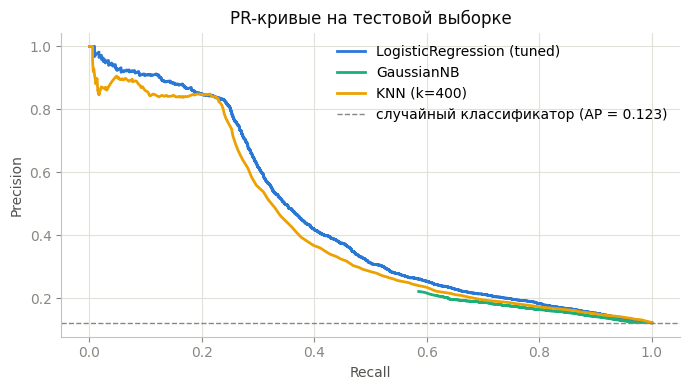

,test AUC PR (my),test AUC PR (sklearn),test Gini
model,,,
LogisticRegression (tuned),0.4487,0.4487,0.4926
GaussianNB,0.1993,0.1993,0.3438
KNN (k=400),0.4172,0.4172,0.4653


In [26]:
best_k = int(knn_grid["valid Gini"].idxmax())
knn_best = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1).fit(X_train_fe, y_train)

test_models = {
    "LogisticRegression (tuned)": best_model,
    "GaussianNB": fe_models["GaussianNB"],
    f"KNN (k={best_k})": knn_best,
}

rows, curves = [], {}
for name, model in test_models.items():
    proba = model.predict_proba(X_test_fe)[:, 1]
    curves[name] = my_precision_recall_curve(y_test, proba)
    rows.append({
        "model": name,
        "test AUC PR (my)": round(my_average_precision(y_test, proba), 4),
        "test AUC PR (sklearn)": round(skm.average_precision_score(y_test, proba), 4),
        "test Gini": round(my_gini(y_test, proba), 4),
    })
results_test = pd.DataFrame(rows).set_index("model")

fig, ax = plt.subplots(figsize=(7, 4))
for (name, (precision, recall)), color in zip(curves.items(), [C_BLUE, C_AQUA, C_YELLOW]):
    ax.plot(recall, precision, linewidth=2, color=color, label=name)
ax.axhline(y_test.mean(), color=C_MUTED, linewidth=1, linestyle="--",
           label=f"случайный классификатор (AP = {y_test.mean():.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("PR-кривые на тестовой выборке")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

results_test

Порядок моделей по AUC PR тот же, что и по Gini: логистическая регрессия впереди.
Заметим, что базовый уровень AUC PR — не 0.5, как у ROC AUC, а доля положительного класса
(~0.12): любая модель выше пунктирной линии уже несёт сигнал.

## Шаг 12. Какая hard-label метрика предпочтительнее для детекции «лимонов»?

Положительный класс — «лимон». Цены ошибок несимметричны:

* **FN** (пропустили «лимон») — дилер покупает машину, которую не сможет перепродать:
  прямой убыток в тысячи долларов за штуку.
* **FP** (хорошую машину пометили как «лимон») — дилер просто отказался от одной из многих
  сделок на аукционе: небольшая упущенная выгода, аналогичных машин на рынке достаточно.

Поэтому из hard-label метрик приоритетен **Recall** — важно отловить как можно больше плохих машин.
Но максимизировать recall «в лоб» нельзя: модель, помечающая всё подряд как «лимон», даст
recall = 1 и остановит закупки вовсе. Разумный единый критерий — **F-beta с β > 1** (например, F2),
который взвешивает recall выше precision, но не даёт ему выродиться.

*(Ответ на вопрос из введения README: больший вес Recall в F-beta даёт **β > 1**;
при β < 1 метрика смещается в сторону Precision.)*

Практичная альтернатива: максимизировать Recall при ограничении снизу на Precision,
подобрав порог по PR-кривой из шага 11 под бизнес-ограничения конкретного дилера.

## Выводы

1. Временной сплит по `PurchDate` (треть дат / треть / треть) — честная схема валидации
   для данных с дрейфом во времени; тест использован ровно один раз.
2. Все три алгоритма прошли порог Gini ≥ 0.15 на валидации; лучший — логистическая регрессия,
   и на тесте она подтвердила лидерство как по Gini, так и по AUC PR.
3. Собственные реализации Gini, ROC AUC, Precision/Recall/F1/AUC PR совпали со sklearn,
   собственные LogisticRegression (SGD), GaussianNB и KNN воспроизвели качество sklearn-моделей.
4. Нелинейные признаки (отношения цен и groupby-агрегаты) дали прирост Gini линейной модели
   и KNN; наивному Байесу скоррелированные признаки, наоборот, вредят.
5. L1-регуляризация отбирает признаки не хуже ручного отбора по весам и делает это автоматически.
6. Финальная модель — LogisticRegression с L1-регуляризацией на расширенных признаках;
   test Gini не уступает valid Gini, модель не переобучена и устойчива к сдвигу во времени.
7. Главный практический урок: признаки, почти пустые в train (`PRIMEUNIT`, `AUCGUART`),
   со временем начинают заполняться и меняют смысл — не выброси мы их на этапе препроцессинга,
   test Gini упал бы в полтора раза при идеальном valid Gini.